# Proyecto MATE / Isolation — Evidencia experimental

Este notebook genera evidencia para el informe a partir de la implementación existente y del experimento final. El lote analizado utilizó **400 partidas por enfrentamiento** y profundidades **1, 2 y 3**; no se vuelve a ejecutar aquí.

## 2. Imports y rutas

In [1]:
from pathlib import Path
import random
import shutil
import subprocess
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display

from board import Board
from mate_agents import AlphaBetaAgent, ExpectimaxAgent, MinimaxAgent
from mate_evaluations import EVALUATION_FUNCTIONS, balanced_eval
from random_agent import RandomAgent

RESULTS_PATH = Path("results/core_400_d123/mate_experiments.csv")
ASSETS_DIR = Path("results/report_assets")
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"No existe el resultado final requerido: {RESULTS_PATH}. "
        "No se cargarán resultados anteriores automáticamente."
    )
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Python activo: {sys.executable}")
print(f"Resultados finales: {RESULTS_PATH}")
print(f"Assets del informe: {ASSETS_DIR}")

def save_table_png(table_df, filename, title):
    shown = table_df.copy().astype(str)
    width = max(9, 1.45 * len(shown.columns))
    height = max(2.5, 0.48 * (len(shown) + 2))
    fig, ax = plt.subplots(figsize=(width, height))
    ax.axis("off")
    ax.set_title(title, fontsize=13, pad=12)
    rendered = ax.table(
        cellText=shown.values, colLabels=shown.columns, loc="center", cellLoc="center"
    )
    rendered.auto_set_font_size(False)
    rendered.set_fontsize(8)
    rendered.scale(1, 1.35)
    rendered.auto_set_column_width(col=list(range(len(shown.columns))))
    fig.tight_layout()
    fig.savefig(ASSETS_DIR / filename, dpi=180, bbox_inches="tight")
    plt.close(fig)

Python activo: /Users/gabo/Desktop/Facultad/Inteligencia Artificial/Obligatorio Marzo 2026/Isolation/.venv/bin/python
Resultados finales: results/core_400_d123/mate_experiments.csv
Assets del informe: results/report_assets


## 3. Evidencia del tablero y las acciones

Isolation utiliza un tablero 4×4. Cada acción tiene la forma `(dirección, casilla_a_eliminar)`.

columna,0,1,2,3
fila,,,,
0,·,·,·,J1
1,·,J2,·,·
2,·,·,·,·
3,·,·,·,·


Posición jugador 1: (0, 3)
Posición jugador 2: (1, 1)
Acciones posibles para jugador 1: 39


,direction,cell_to_destroy_row,cell_to_destroy_col
0,1,0,0
1,1,0,1
2,1,0,2
3,1,1,0
4,1,1,2
5,1,2,0
6,1,2,1
7,1,2,2
8,1,2,3
9,1,3,0


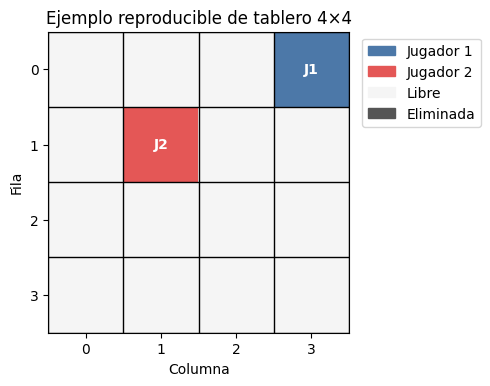

In [2]:
random.seed(2026)
board = Board((4, 4))
board_symbols = {0: "·", 1: "J1", 2: "J2", 3: "X"}
board_table = pd.DataFrame(board.grid).replace(board_symbols)
board_table.index.name = "fila"
board_table.columns.name = "columna"
display(board_table)
print("Posición jugador 1:", board.find_player_position(1))
print("Posición jugador 2:", board.find_player_position(2))
possible_actions = board.get_possible_actions(1)
print("Acciones posibles para jugador 1:", len(possible_actions))

board_possible_actions = pd.DataFrame(
    [
        {
            "direction": direction,
            "cell_to_destroy_row": cell[0],
            "cell_to_destroy_col": cell[1],
        }
        for direction, cell in possible_actions[:10]
    ]
)
display(board_possible_actions)
board_possible_actions.to_csv(ASSETS_DIR / "board_possible_actions.csv", index=False)

cmap = ListedColormap(["#f5f5f5", "#4C78A8", "#E45756", "#555555"])
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(board.grid, cmap=cmap, vmin=0, vmax=3)
ax.set_xticks(np.arange(4)); ax.set_yticks(np.arange(4))
ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
ax.grid(which="minor", color="black", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)
labels = {0: "", 1: "J1", 2: "J2", 3: "X"}
for row in range(4):
    for col in range(4):
        ax.text(col, row, labels[int(board.grid[row, col])], ha="center", va="center", color="white", weight="bold")
ax.set(title="Ejemplo reproducible de tablero 4×4", xlabel="Columna", ylabel="Fila")
ax.legend(handles=[
    Patch(color="#4C78A8", label="Jugador 1"),
    Patch(color="#E45756", label="Jugador 2"),
    Patch(color="#f5f5f5", label="Libre"),
    Patch(color="#555555", label="Eliminada"),
], loc="upper left", bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(ASSETS_DIR / "board_example.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Validación de acciones legales

Antes de analizar resultados, verificamos que cada agente elija una acción generada por el tablero.

In [3]:
agents = {
    "RandomAgent": RandomAgent(player=1, seed=2026),
    "MinimaxAgent": MinimaxAgent(player=1, depth=2, evaluation_function=balanced_eval, seed=2026),
    "AlphaBetaAgent": AlphaBetaAgent(player=1, depth=2, evaluation_function=balanced_eval, seed=2026),
    "ExpectimaxAgent": ExpectimaxAgent(player=1, depth=2, evaluation_function=balanced_eval, seed=2026),
}
legal_action_validation = pd.DataFrame([
    {"agent": name, "selected_action": str(action), "is_legal": action in possible_actions}
    for name, agent in agents.items()
    for action in [agent.next_action(board.clone())]
])
display(legal_action_validation)
assert legal_action_validation["is_legal"].all()
legal_action_validation.to_csv(ASSETS_DIR / "legal_action_validation.csv", index=False)

,agent,selected_action,is_legal
0,RandomAgent,"(1, (2, 2))",True
1,MinimaxAgent,"(6, (3, 1))",True
2,AlphaBetaAgent,"(6, (3, 1))",True
3,ExpectimaxAgent,"(6, (1, 0))",True


## 5. Evidencia de tests

Los tests validan acciones legales, partidas completas, equivalencia Minimax/Alpha-Beta y que la búsqueda no corrompa el tablero real.

In [4]:
test_command = (
    ["poetry", "run", "python", "-m", "unittest", "discover", "-s", "tests", "-v"]
    if shutil.which("poetry")
    else [sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"]
)
test_process = subprocess.run(test_command, capture_output=True, text=True)
tests_output = test_process.stdout + test_process.stderr
print(tests_output)
(ASSETS_DIR / "tests_output.txt").write_text(tests_output, encoding="utf-8")
if test_process.returncode != 0:
    raise RuntimeError("Los tests de MATE fallaron; revisar tests_output.txt")

test_clone_preserves_rectangular_size_and_is_independent (test_mate.BoardTests) ... ok
test_generated_actions_are_accepted_on_a_clone (test_mate.BoardTests) ... ok
test_all_evaluations_are_numeric_and_bounded (test_mate.EvaluationTests) ... ok
test_agents_return_none_when_player_has_no_move (test_mate.SearchAgentTests) ... ok
test_all_agents_choose_legal_actions_without_mutating_board (test_mate.SearchAgentTests) ... ok
test_depth_one_agent_can_finish_a_game (test_mate.SearchAgentTests) ... ok
test_minimax_and_alpha_beta_agree_and_alpha_beta_visits_no_more_nodes (test_mate.SearchAgentTests) ... ok

----------------------------------------------------------------------
Ran 7 tests in 0.059s

OK



## 6. Carga del experimento final

In [5]:
df = pd.read_csv(RESULTS_PATH)
required_columns = {
    "matchup", "agent_name", "opponent_name", "evaluation_function",
    "search_depth", "games", "wins", "losses", "win_rate",
    "average_game_length", "average_decision_time_seconds",
    "average_expanded_nodes", "average_pruned_branches",
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {sorted(missing_columns)}")
if not df["games"].eq(400).all():
    raise ValueError("El CSV no corresponde al experimento final de 400 partidas por enfrentamiento")
display(df.head())
print("Shape:", df.shape)
print(f"Final experiment loaded: {len(df)} rows, 400 games per matchup")
df.to_csv(ASSETS_DIR / "final_results_loaded.csv", index=False)

,matchup,agent_name,opponent_name,evaluation_function,search_depth,games,wins,losses,win_rate,average_game_length,average_decision_time_seconds,average_expanded_nodes,average_pruned_branches
0,"Minimax[balanced,d=1]_vs_Random",Minimax,Random,balanced,1,400,384,16,0.9600,4.5800,0.000706,40.486111,0.0
1,"Minimax[balanced,d=1]_vs_Random",Random,Minimax,none,0,400,16,384,0.0400,4.5800,0.000017,0.000000,0.0
2,"AlphaBeta[balanced,d=1]_vs_Random",AlphaBeta,Random,balanced,1,400,391,9,0.9775,4.6075,0.000691,39.744346,0.0
3,"AlphaBeta[balanced,d=1]_vs_Random",Random,AlphaBeta,none,0,400,9,391,0.0225,4.6075,0.000017,0.000000,0.0
4,"Expectimax[balanced,d=1]_vs_Random",Expectimax,Random,balanced,1,400,381,19,0.9525,4.6525,0.000683,39.856024,0.0


Shape: (40, 13)
Final experiment loaded: 40 rows, 400 games per matchup


## 7. Parámetros del experimento

In [6]:
experiment_parameters = pd.DataFrame({
    "Parámetro": ["Tablero", "Partidas por enfrentamiento", "Profundidades", "Agentes", "Funciones de evaluación", "Métricas", "Ruta de resultados"],
    "Valor": [
        "4x4", "400", "1, 2, 3",
        "Minimax, Alpha-Beta, Expectimax, RandomAgent",
        "mobility, aggressive, defensive, balanced, territory, weighted",
        "win rate, tiempo, nodos, podas, longitud de partida",
        RESULTS_PATH.as_posix(),
    ],
})
display(experiment_parameters)
experiment_parameters.to_csv(ASSETS_DIR / "experiment_parameters.csv", index=False)
save_table_png(experiment_parameters, "experiment_parameters.png", "Parámetros del experimento final")

,Parámetro,Valor
0,Tablero,4x4
1,Partidas por enfrentamiento,400
2,Profundidades,"1, 2, 3"
3,Agentes,"Minimax, Alpha-Beta, Expectimax, RandomAgent"
4,Funciones de evaluación,"mobility, aggressive, defensive, balanced, ter..."
5,Métricas,"win rate, tiempo, nodos, podas, longitud de pa..."
6,Ruta de resultados,results/core_400_d123/mate_experiments.csv


## 8. Tabla principal de resultados

In [7]:
main_results_table = df[df["agent_name"] != "Random"].copy()
main_results_table["win_rate_percent"] = (100 * main_results_table["win_rate"]).round(1)
main_results_table = main_results_table[[
    "agent_name", "opponent_name", "evaluation_function", "search_depth",
    "games", "wins", "losses", "win_rate_percent", "average_game_length",
    "average_decision_time_seconds", "average_expanded_nodes", "average_pruned_branches",
]]
main_results_table["average_game_length"] = main_results_table["average_game_length"].round(1)
main_results_table["average_decision_time_seconds"] = main_results_table["average_decision_time_seconds"].round(4)
main_results_table["average_expanded_nodes"] = main_results_table["average_expanded_nodes"].round(1)
main_results_table["average_pruned_branches"] = main_results_table["average_pruned_branches"].round(1)
main_results_table = main_results_table.sort_values(
    ["win_rate_percent", "average_decision_time_seconds", "average_expanded_nodes"],
    ascending=[False, True, True],
).head(10).reset_index(drop=True)
display(main_results_table)
main_results_table.to_csv(ASSETS_DIR / "main_results_table.csv", index=False)
save_table_png(main_results_table, "main_results_table.png", "Diez configuraciones con mayor desempeño")

,agent_name,opponent_name,evaluation_function,search_depth,games,wins,losses,win_rate_percent,average_game_length,average_decision_time_seconds,average_expanded_nodes,average_pruned_branches
0,Expectimax,Random,balanced,3,400,398,2,99.5,4.9,0.4294,24038.7,0.0
1,AlphaBeta,Random,balanced,3,400,394,6,98.5,5.2,0.0468,2512.5,3951.9
2,AlphaBeta,Random,weighted,3,400,393,7,98.2,5.2,0.0624,2465.1,3796.2
3,Minimax,Random,balanced,3,400,393,7,98.2,5.3,0.3790,21314.3,0.0
4,AlphaBeta,Random,balanced,1,400,391,9,97.8,4.6,0.0007,39.7,0.0
5,AlphaBeta,Random,defensive,3,400,391,9,97.8,5.3,0.0302,2016.2,3064.9
6,AlphaBeta,Random,territory,3,400,391,9,97.8,5.2,0.0644,2163.3,3701.0
7,AlphaBeta,Random,mobility,3,400,390,10,97.5,5.1,0.0421,2335.2,3765.7
8,Minimax,Random,balanced,2,400,386,14,96.5,4.9,0.0178,1024.5,0.0
9,Expectimax,Random,balanced,2,400,386,14,96.5,4.7,0.0180,1048.2,0.0


## 9. Comparación de profundidad

,agent_name,search_depth,win_rate_percent,avg_time_seconds,avg_expanded_nodes,avg_pruned_branches,observed_result
0,AlphaBeta,1,97.8,0.0007,39.7,0.0,bajo costo
1,AlphaBeta,2,96.2,0.0045,254.8,777.7,costo intermedio
2,AlphaBeta,3,98.5,0.0468,2512.5,3951.9,"mayor costo, más búsqueda"
3,Expectimax,1,95.2,0.0007,39.9,0.0,bajo costo
4,Expectimax,2,96.5,0.0180,1048.2,0.0,costo intermedio
5,Expectimax,3,99.5,0.4294,24038.7,0.0,"mayor costo, más búsqueda"
6,Minimax,1,96.0,0.0007,40.5,0.0,bajo costo
7,Minimax,2,96.5,0.0178,1024.5,0.0,costo intermedio
8,Minimax,3,98.2,0.3790,21314.3,0.0,"mayor costo, más búsqueda"


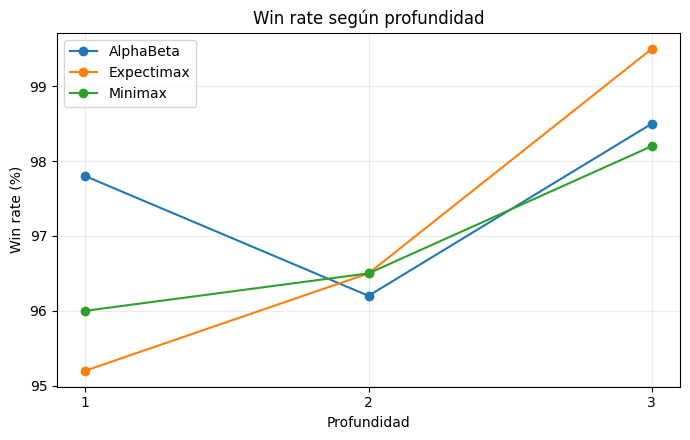

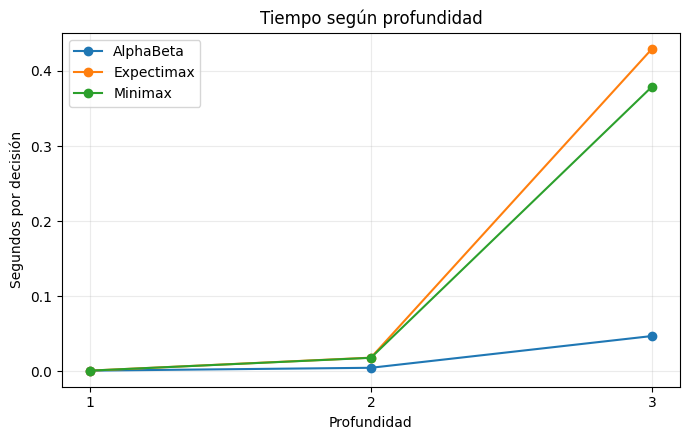

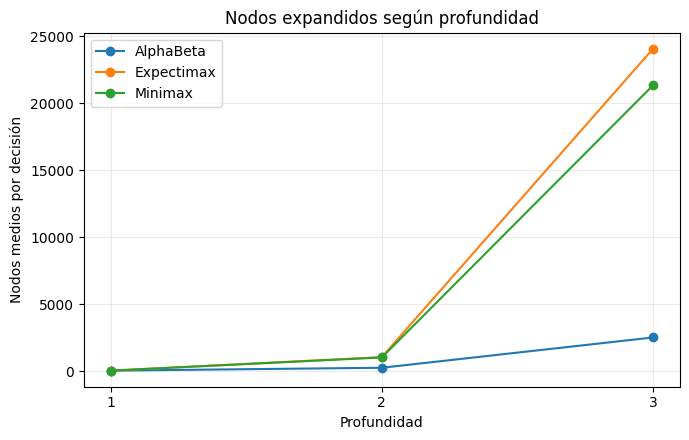

In [8]:
depth_source = df[
    (df["evaluation_function"] == "balanced")
    & (df["opponent_name"] == "Random")
    & (df["agent_name"].isin(["Minimax", "AlphaBeta", "Expectimax"]))
]
depth_comparison = depth_source.groupby(["agent_name", "search_depth"], as_index=False).agg(
    win_rate=("win_rate", "mean"),
    avg_time_seconds=("average_decision_time_seconds", "mean"),
    avg_expanded_nodes=("average_expanded_nodes", "mean"),
    avg_pruned_branches=("average_pruned_branches", "mean"),
)
depth_comparison["win_rate_percent"] = (100 * depth_comparison.pop("win_rate")).round(1)
depth_comparison["observed_result"] = depth_comparison["search_depth"].map({1: "bajo costo", 2: "costo intermedio", 3: "mayor costo, más búsqueda"})
depth_comparison = depth_comparison[["agent_name", "search_depth", "win_rate_percent", "avg_time_seconds", "avg_expanded_nodes", "avg_pruned_branches", "observed_result"]]
depth_comparison[["avg_time_seconds", "avg_expanded_nodes", "avg_pruned_branches"]] = depth_comparison[["avg_time_seconds", "avg_expanded_nodes", "avg_pruned_branches"]].round({"avg_time_seconds": 4, "avg_expanded_nodes": 1, "avg_pruned_branches": 1})
display(depth_comparison)
depth_comparison.to_csv(ASSETS_DIR / "depth_comparison.csv", index=False)
save_table_png(depth_comparison, "depth_comparison.png", "Comparación por profundidad")

for metric, ylabel, filename, title in [
    ("win_rate_percent", "Win rate (%)", "mate_depth_win_rate.png", "Win rate según profundidad"),
    ("avg_time_seconds", "Segundos por decisión", "mate_depth_decision_time.png", "Tiempo según profundidad"),
    ("avg_expanded_nodes", "Nodos medios por decisión", "mate_depth_expanded_nodes.png", "Nodos expandidos según profundidad"),
]:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for agent_name, group in depth_comparison.groupby("agent_name"):
        ax.plot(group["search_depth"], group[metric], marker="o", label=agent_name)
    ax.set(title=title, xlabel="Profundidad", ylabel=ylabel, xticks=[1, 2, 3])
    ax.grid(alpha=0.25); ax.legend()
    fig.tight_layout(); fig.savefig(ASSETS_DIR / filename, dpi=180); plt.show()

## 10. Impacto de Alpha-Beta Pruning

,depth,minimax_expanded_nodes,alphabeta_expanded_nodes,alphabeta_pruned_branches,minimax_time_seconds,alphabeta_time_seconds,comment
0,1,31.8,32.0,0.0,0.0006,0.0006,No se observó reducción en esta corrida
1,2,1145.4,275.7,886.1,0.0200,0.0051,Alpha-Beta expandió menos nodos
2,3,24617.9,2869.1,4484.6,0.4394,0.0529,Alpha-Beta expandió menos nodos


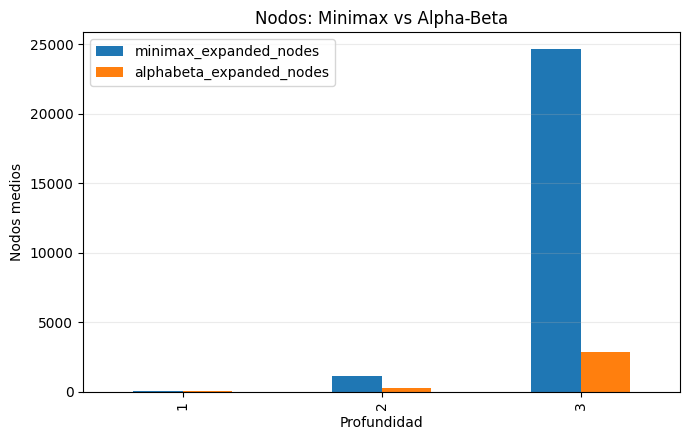

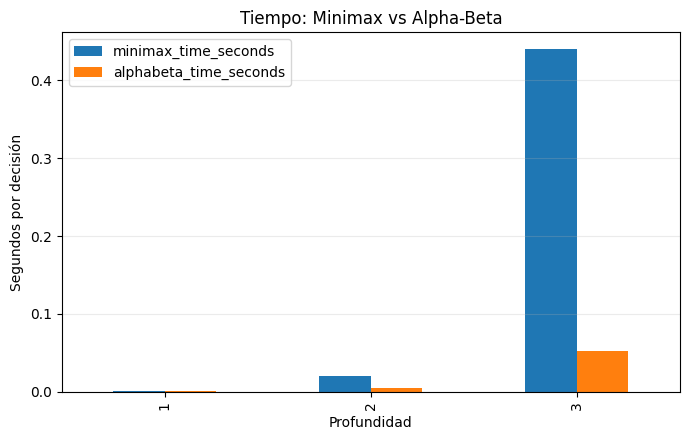

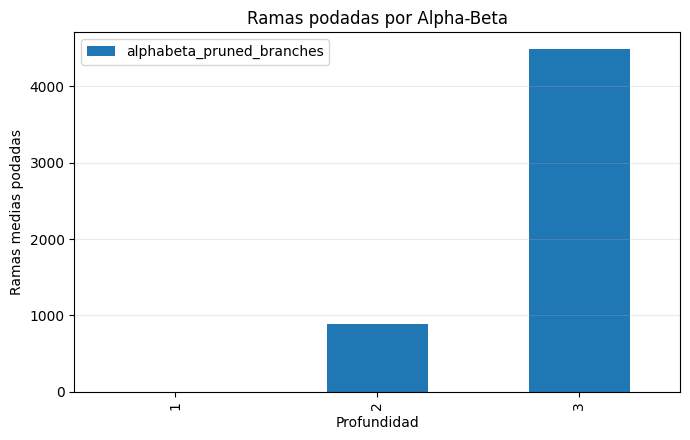

In [9]:
alphabeta_rows = []
for depth in (1, 2, 3):
    matchup_name = f"AlphaBeta[balanced,d={depth}]_vs_Minimax[balanced,d={depth}]"
    direct = df[df["matchup"] == matchup_name]
    alpha_row = direct[direct["agent_name"] == "AlphaBeta"].iloc[0]
    minimax_row = direct[direct["agent_name"] == "Minimax"].iloc[0]
    reduced = alpha_row["average_expanded_nodes"] < minimax_row["average_expanded_nodes"]
    alphabeta_rows.append({
        "depth": depth,
        "minimax_expanded_nodes": minimax_row["average_expanded_nodes"],
        "alphabeta_expanded_nodes": alpha_row["average_expanded_nodes"],
        "alphabeta_pruned_branches": alpha_row["average_pruned_branches"],
        "minimax_time_seconds": minimax_row["average_decision_time_seconds"],
        "alphabeta_time_seconds": alpha_row["average_decision_time_seconds"],
        "comment": "Alpha-Beta expandió menos nodos" if reduced else "No se observó reducción en esta corrida",
    })
alphabeta_impact = pd.DataFrame(alphabeta_rows).round({
    "minimax_expanded_nodes": 1, "alphabeta_expanded_nodes": 1,
    "alphabeta_pruned_branches": 1, "minimax_time_seconds": 4,
    "alphabeta_time_seconds": 4,
})
display(alphabeta_impact)
alphabeta_impact.to_csv(ASSETS_DIR / "alphabeta_impact.csv", index=False)
save_table_png(alphabeta_impact, "alphabeta_impact.png", "Impacto de Alpha-Beta Pruning")

for columns, ylabel, filename, title in [
    (["minimax_expanded_nodes", "alphabeta_expanded_nodes"], "Nodos medios", "mate_alphabeta_nodes.png", "Nodos: Minimax vs Alpha-Beta"),
    (["minimax_time_seconds", "alphabeta_time_seconds"], "Segundos por decisión", "mate_alphabeta_time.png", "Tiempo: Minimax vs Alpha-Beta"),
    (["alphabeta_pruned_branches"], "Ramas medias podadas", "mate_alphabeta_pruning.png", "Ramas podadas por Alpha-Beta"),
]:
    ax = alphabeta_impact.set_index("depth")[columns].plot(kind="bar", figsize=(7, 4.5))
    ax.set(title=title, xlabel="Profundidad", ylabel=ylabel)
    ax.grid(axis="y", alpha=0.25); ax.figure.tight_layout()
    ax.figure.savefig(ASSETS_DIR / filename, dpi=180); plt.show()

## 11. Comparación de funciones de evaluación

,evaluation_function,win_rate_percent,average_decision_time_seconds,average_expanded_nodes,average_pruned_branches,observation
0,balanced,98.5,0.0468,2512.5,3951.9,mejor win rate
1,weighted,98.2,0.0624,2465.1,3796.2,resultado intermedio
2,defensive,97.8,0.0302,2016.2,3064.9,resultado intermedio
3,territory,97.8,0.0644,2163.3,3701.0,resultado intermedio
4,mobility,97.5,0.0421,2335.2,3765.7,resultado intermedio
5,aggressive,96.5,0.0268,1767.6,3632.7,menor tiempo


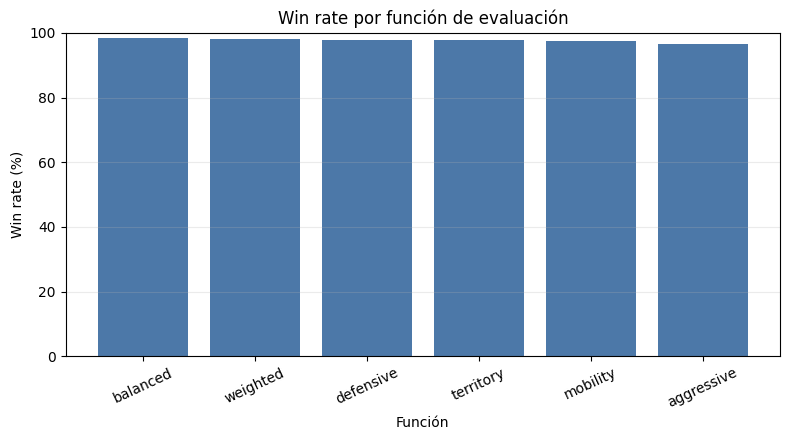

In [10]:
evaluation_comparison = df[
    (df["agent_name"] == "AlphaBeta")
    & (df["opponent_name"] == "Random")
    & (df["search_depth"] == 3)
    & (df["evaluation_function"].isin(EVALUATION_FUNCTIONS))
][["evaluation_function", "win_rate", "average_decision_time_seconds", "average_expanded_nodes", "average_pruned_branches"]].copy()
evaluation_comparison["win_rate_percent"] = (100 * evaluation_comparison.pop("win_rate")).round(1)
best_win = evaluation_comparison["win_rate_percent"].max()
best_time = evaluation_comparison["average_decision_time_seconds"].min()
evaluation_comparison["observation"] = evaluation_comparison.apply(
    lambda row: "mejor win rate" if row["win_rate_percent"] == best_win
    else ("menor tiempo" if row["average_decision_time_seconds"] == best_time else "resultado intermedio"), axis=1
)
evaluation_comparison = evaluation_comparison[["evaluation_function", "win_rate_percent", "average_decision_time_seconds", "average_expanded_nodes", "average_pruned_branches", "observation"]]
evaluation_comparison = evaluation_comparison.sort_values(["win_rate_percent", "average_decision_time_seconds"], ascending=[False, True]).reset_index(drop=True)
evaluation_comparison = evaluation_comparison.round({"average_decision_time_seconds": 4, "average_expanded_nodes": 1, "average_pruned_branches": 1})
display(evaluation_comparison)
evaluation_comparison.to_csv(ASSETS_DIR / "evaluation_comparison.csv", index=False)
save_table_png(evaluation_comparison, "evaluation_comparison.png", "Funciones de evaluación con Alpha-Beta (d=3)")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(evaluation_comparison["evaluation_function"], evaluation_comparison["win_rate_percent"], color="#4C78A8")
ax.set(title="Win rate por función de evaluación", xlabel="Función", ylabel="Win rate (%)", ylim=(0, 100))
ax.tick_params(axis="x", rotation=25); ax.grid(axis="y", alpha=0.25)
fig.tight_layout(); fig.savefig(ASSETS_DIR / "mate_eval_win_rate.png", dpi=180); plt.show()

## 12. Selección del agente final

In [11]:
candidates = df[(df["opponent_name"] == "Random") & (df["agent_name"] != "Random")].copy()
selected = candidates.sort_values(
    ["win_rate", "average_decision_time_seconds", "average_expanded_nodes"],
    ascending=[False, True, True],
).iloc[0]
justification = "Se seleccionó esta configuración porque obtuvo el mejor equilibrio entre win rate y costo computacional dentro de las configuraciones evaluadas."
final_agent_selection = pd.DataFrame({
    "criterion": ["Agente", "Función de evaluación", "Profundidad", "Win rate", "Tiempo promedio", "Nodos expandidos", "Ramas podadas", "Justificación"],
    "selected_value": [
        selected["agent_name"], selected["evaluation_function"], int(selected["search_depth"]),
        f"{100 * selected['win_rate']:.1f}%", f"{selected['average_decision_time_seconds']:.4f} s",
        f"{selected['average_expanded_nodes']:.1f}", f"{selected['average_pruned_branches']:.1f}", justification,
    ],
})
display(final_agent_selection)
final_agent_selection.to_csv(ASSETS_DIR / "final_agent_selection.csv", index=False)
save_table_png(final_agent_selection, "final_agent_selection.png", "Selección del agente final")
final_agent_text = (
    f"El agente final elegido fue {selected['agent_name']} con heurística {selected['evaluation_function']} "
    f"y profundidad {int(selected['search_depth'])}, ya que obtuvo un win rate de {100 * selected['win_rate']:.1f}% "
    f"con un tiempo promedio de decisión de {selected['average_decision_time_seconds']:.4f} segundos. "
    "Esta configuración presentó el mejor equilibrio entre desempeño y costo computacional dentro de las pruebas realizadas."
)
print(final_agent_text)
(ASSETS_DIR / "final_agent_text.md").write_text(final_agent_text + "\n", encoding="utf-8")

,criterion,selected_value
0,Agente,Expectimax
1,Función de evaluación,balanced
2,Profundidad,3
3,Win rate,99.5%
4,Tiempo promedio,0.4294 s
5,Nodos expandidos,24038.7
6,Ramas podadas,0.0
7,Justificación,Se seleccionó esta configuración porque obtuvo...


El agente final elegido fue Expectimax con heurística balanced y profundidad 3, ya que obtuvo un win rate de 99.5% con un tiempo promedio de decisión de 0.4294 segundos. Esta configuración presentó el mejor equilibrio entre desempeño y costo computacional dentro de las pruebas realizadas.


290

## 13. Conclusión lista para el informe

In [12]:
depth3_impact = alphabeta_impact[alphabeta_impact["depth"] == 3].iloc[0]
node_reduction = 100 * (1 - depth3_impact["alphabeta_expanded_nodes"] / depth3_impact["minimax_expanded_nodes"])
mate_conclusion = (
    "Se compararon Minimax, Alpha-Beta y Expectimax en Isolation 4×4 mediante 400 partidas por enfrentamiento. "
    f"La configuración seleccionada fue {selected['agent_name']} con evaluación {selected['evaluation_function']} y profundidad {int(selected['search_depth'])}, "
    f"que alcanzó un win rate de {100 * selected['win_rate']:.1f}% contra Random. "
    f"En el enfrentamiento directo de profundidad 3, Alpha-Beta redujo los nodos medios de {depth3_impact['minimax_expanded_nodes']:.1f} "
    f"a {depth3_impact['alphabeta_expanded_nodes']:.1f}, una reducción de {node_reduction:.1f}%, gracias a la poda. "
    "La profundidad máxima evaluada fue 3 porque el costo computacional crece rápidamente con la profundidad."
)
print(mate_conclusion)
(ASSETS_DIR / "mate_conclusion.md").write_text(mate_conclusion + "\n", encoding="utf-8")

Se compararon Minimax, Alpha-Beta y Expectimax en Isolation 4×4 mediante 400 partidas por enfrentamiento. La configuración seleccionada fue Expectimax con evaluación balanced y profundidad 3, que alcanzó un win rate de 99.5% contra Random. En el enfrentamiento directo de profundidad 3, Alpha-Beta redujo los nodos medios de 24617.9 a 2869.1, una reducción de 88.3%, gracias a la poda. La profundidad máxima evaluada fue 3 porque el costo computacional crece rápidamente con la profundidad.


491

## 14. Assets generados

Los PNG son figuras listas para insertar; los CSV contienen las tablas editables y los Markdown contienen texto listo para copiar.

In [13]:
required_assets = [
    "board_possible_actions.csv", "board_example.png", "legal_action_validation.csv", "tests_output.txt",
    "final_results_loaded.csv", "experiment_parameters.csv", "experiment_parameters.png",
    "main_results_table.csv", "main_results_table.png", "depth_comparison.csv", "depth_comparison.png",
    "mate_depth_win_rate.png", "mate_depth_decision_time.png", "mate_depth_expanded_nodes.png",
    "alphabeta_impact.csv", "alphabeta_impact.png", "mate_alphabeta_nodes.png",
    "mate_alphabeta_time.png", "mate_alphabeta_pruning.png", "evaluation_comparison.csv",
    "evaluation_comparison.png", "mate_eval_win_rate.png", "final_agent_selection.csv",
    "final_agent_selection.png", "final_agent_text.md", "mate_conclusion.md",
]
missing_assets = [name for name in required_assets if not (ASSETS_DIR / name).exists()]
if missing_assets:
    raise RuntimeError(f"No se generaron estos assets: {missing_assets}")
asset_uses = pd.DataFrame({
    "Archivo": required_assets,
    "Uso": [
        "Acciones del tablero", "Figura del tablero", "Validación de agentes", "Validación técnica",
        "Resultados completos", "Diseño experimental", "Diseño experimental",
        "Resultados principales", "Resultados principales", "Comparación de profundidad", "Comparación de profundidad",
        "Profundidad: win rate", "Profundidad: tiempo", "Profundidad: nodos",
        "Impacto de Alpha-Beta", "Impacto de Alpha-Beta", "Alpha-Beta: nodos",
        "Alpha-Beta: tiempo", "Alpha-Beta: podas", "Funciones de evaluación",
        "Funciones de evaluación", "Evaluaciones: win rate", "Selección final",
        "Selección final", "Texto de selección", "Conclusión",
    ],
})
display(asset_uses)
print(f"Generados correctamente {len(required_assets)} archivos en {ASSETS_DIR}")

,Archivo,Uso
0,board_possible_actions.csv,Acciones del tablero
1,board_example.png,Figura del tablero
2,legal_action_validation.csv,Validación de agentes
3,tests_output.txt,Validación técnica
4,final_results_loaded.csv,Resultados completos
5,experiment_parameters.csv,Diseño experimental
6,experiment_parameters.png,Diseño experimental
7,main_results_table.csv,Resultados principales
8,main_results_table.png,Resultados principales
9,depth_comparison.csv,Comparación de profundidad


Generados correctamente 26 archivos en results/report_assets
